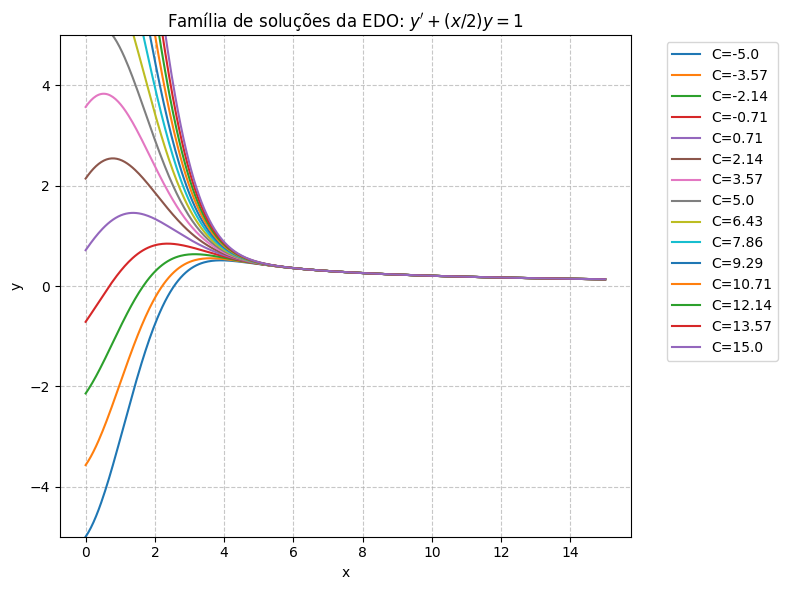

In [196]:
import sympy as sp
import numpy as np
from scipy import special
import matplotlib.pyplot as plt

def solve_linear_ode(p_expr, q_expr, x_var):
    """
    Resolve simbolicamente uma EDO linear de 1ª ordem.
    Retorna a expressão simbólica geral em função de x_var e de uma constante C.
    """
    C = sp.symbols('C')
    mu = sp.exp(sp.integrate(p_expr, x_var))
    integral_part = sp.integrate(mu * q_expr, x_var)
    y_expr = (integral_part + C) / mu
    
    return y_expr, C

def plot_ode_family(y_func, x_range=(0, 15), y_range=(-5, 5), C_values=None):
    """
    Renderiza a família de soluções a partir de uma função numérica pré-compilada.
    """
    x_vals = np.linspace(x_range[0], x_range[1], 400)
    C_values = C_values if C_values is not None else np.linspace(-5, 15, 15)

    plt.figure(figsize=(8, 6))
    
    for c_val in C_values:
        # A avaliação pode gerar números complexos devido ao erf(ix),
        # pegamos a parte real que contém a solução física neste domínio.
        y_vals = np.real(y_func(x_vals, c_val))
        plt.plot(x_vals, y_vals, label=f'C={round(c_val, 2)}')

    plt.title("Família de soluções da EDO: $y' + (x/2)y = 1$")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.ylim(y_range)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    x = sp.symbols('x')
    p = x / 2
    q = 1

    # 1. Resolvemos analiticamente
    y_expr, C = solve_linear_ode(p, q, x)
    
    # 2. Compilamos explicitamente mapeando numpy e scipy
    # Usamos np.vectorize caso a expressão se torne uma constante em algum edge case
    y_func_raw = sp.lambdify((x, C), y_expr, modules=['numpy', 'scipy'])
    
    # 3. Plotamos
    plot_ode_family(y_func_raw)